# 🍷 Wine Quality Prediction Using Machine Learning

##  Objective
The goal of this project is to build a machine learning model that predicts wine quality based on physicochemical properties.

##  Key Questions
- Which features influence wine quality the most?
- Can we accurately classify good vs bad wine?
- Which model performs best?

##  Dataset
The dataset contains chemical properties of red wine samples such as acidity, alcohol, pH, and sulphates.

## Importing Libraries
We import the necessary libraries for data manipulation, visualization, and modeling.

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Understanding the Data
We inspect the structure, data types, and basic statistics of the dataset.

In [381]:
df = pd.read_csv("data/winequalityN.csv")
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Understanding the Data
We inspect the structure, data types, and basic statistics of the dataset.

In [382]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [383]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [384]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

## Data Cleaning
fixing missing values

In [385]:
df["fixed acidity"] = df["fixed acidity"].fillna(df["fixed acidity"].median())
df["volatile acidity"] = df["volatile acidity"].fillna(df["volatile acidity"].median())
df["citric acid"] = df["citric acid"].fillna(df["citric acid"].median())
df["residual sugar"] = df["residual sugar"].fillna(df["residual sugar"].median())
df["chlorides"] = df["chlorides"].fillna(df["chlorides"].median())
df["pH"] = df["pH"].fillna(df["pH"].median())
df["sulphates"] = df["sulphates"].fillna(df["sulphates"].median())
df["alcohol"] = df["alcohol"].fillna(df["alcohol"].median())
print("Missing values AFTER cleaning:")
print(df.isnull().sum())

Missing values AFTER cleaning:
type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


confirming duplicates before deciding whether to drop

In [386]:
print("Duplicates BEFORE:", df.duplicated().sum())

Duplicates BEFORE: 1168


In [387]:
print("Duplicates AFTER:", df.duplicated().sum())
print("Shape AFTER removing duplicates:", df.shape)

Duplicates AFTER: 1168
Shape AFTER removing duplicates: (6497, 13)


checking for data types

In [388]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None


checking for outliers
dots outside whiskers = outliers

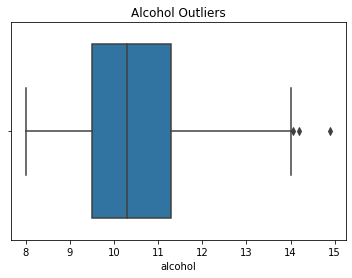

In [389]:
sns.boxplot(x=df["alcohol"])
plt.title("Alcohol Outliers")
plt.show()

Removing outliers

In [390]:
print("Shape BEFORE outlier removal:", df.shape)

df = df[df["alcohol"] < 15]
df = df[df["alcohol"] > 8]

print("Shape AFTER alcohol filter:", df.shape)

Shape BEFORE outlier removal: (6497, 13)
Shape AFTER alcohol filter: (6495, 13)


Converting target variable

In [391]:
print("Original quality values:")
print(df["quality"].value_counts())

Original quality values:
6    2836
5    2137
7    1079
4     216
8     193
3      29
9       5
Name: quality, dtype: int64


converting and verifying target variables


In [392]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

In [393]:
print("After conversion:")
print(df["quality"].value_counts())

After conversion:
0    5218
1    1277
Name: quality, dtype: int64


final datset

In [394]:
print("FINAL SHAPE:", df.shape)
df.head()

FINAL SHAPE: (6495, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,0
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,0
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,0
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0


#  Exploratory Data Analysis (EDA)

## Objective
The goal of this analysis is to understand the structure of the wine dataset, identify key patterns, and determine which chemical properties most influence wine quality.

We will go beyond simple visualization and focus on:
- Distribution analysis
- Relationship strength between variables
- Class separation ability
- Data quality issues and biases

In [395]:
print("FINAL SHAPE:", df.shape)
df.info()

FINAL SHAPE: (6495, 13)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6495 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6495 non-null   object 
 1   fixed acidity         6495 non-null   float64
 2   volatile acidity      6495 non-null   float64
 3   citric acid           6495 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6495 non-null   float64
 7   total sulfur dioxide  6495 non-null   float64
 8   density               6495 non-null   float64
 9   pH                    6495 non-null   float64
 10  sulphates             6495 non-null   float64
 11  alcohol               6495 non-null   float64
 12  quality               6495 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 710.4+ KB


## Data Structure Insight

The dataset contains multiple physicochemical properties of wine samples.

All features are numerical, which makes it suitable for machine learning without extensive encoding.

In [396]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## Missing Data Insight

We observe missing values in several chemical properties.

This suggests data collection inconsistencies in wine testing, which is common in real-world datasets.

# Distribution analysis

array([[<AxesSubplot:title={'center':'fixed acidity'}>,
        <AxesSubplot:title={'center':'volatile acidity'}>,
        <AxesSubplot:title={'center':'citric acid'}>],
       [<AxesSubplot:title={'center':'residual sugar'}>,
        <AxesSubplot:title={'center':'chlorides'}>,
        <AxesSubplot:title={'center':'free sulfur dioxide'}>],
       [<AxesSubplot:title={'center':'total sulfur dioxide'}>,
        <AxesSubplot:title={'center':'density'}>,
        <AxesSubplot:title={'center':'pH'}>],
       [<AxesSubplot:title={'center':'sulphates'}>,
        <AxesSubplot:title={'center':'alcohol'}>,
        <AxesSubplot:title={'center':'quality'}>]], dtype=object)

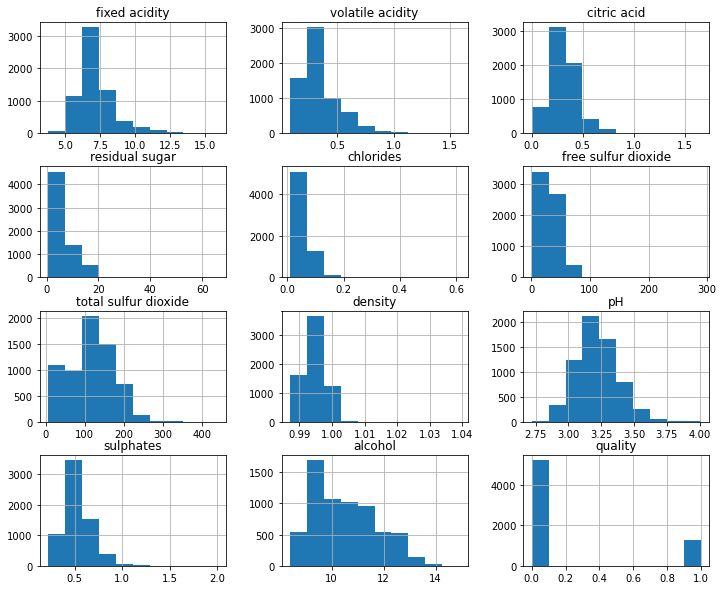

In [397]:
df.hist(figsize=(12,10))

## Feature Distribution Insight

Several variables such as alcohol, sulphates, and acidity show skewed distributions.

This indicates:
- Presence of extreme values
- Non-normal distributions
- Need for scaling or transformation in modeling

# target bias analysis

In [398]:

df["quality"].value_counts(normalize=True)

0    0.803387
1    0.196613
Name: quality, dtype: float64

## Class Balance Insight

The dataset is imbalanced, with one class dominating.

This is important because:
- It may bias the model toward majority class
- Accuracy alone will not be a reliable metric
- We will need precision/recall later

# future relationship strength 

In [399]:
corr = df.corr()
corr["quality"].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.390445
citric acid             0.054091
sulphates               0.034099
pH                      0.027874
free sulfur dioxide     0.015179
fixed acidity          -0.049968
total sulfur dioxide   -0.051118
residual sugar         -0.064057
volatile acidity       -0.151580
chlorides              -0.161960
density                -0.275446
Name: quality, dtype: float64

## Feature Importance Insight (Correlation-Based)

We observe that:

- Alcohol shows the strongest positive correlation with quality
- Volatile acidity shows a strong negative correlation
- Sulphates also contribute positively

This suggests that wine quality is strongly influenced by alcohol content and acidity balance.

# multivariate relationship

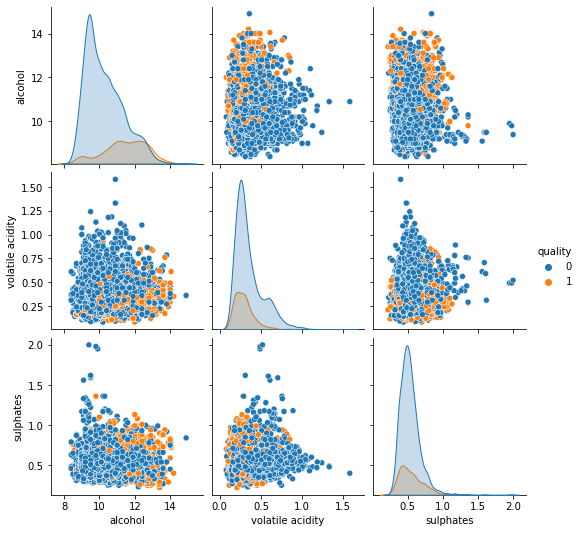

In [400]:
sns.pairplot(df[["alcohol", "volatile acidity", "sulphates", "quality"]], hue="quality")

## Feature Interaction Insight

We observe partial separation between good and bad wines in feature space.

However, overlap exists, meaning:
- The problem is not linearly separable
- More powerful models like Random Forest may perform better than linear models

# key insights

## Key Analytical Insight

From the analysis:

- Wine quality is not determined by a single feature but a combination of chemical properties.
- Alcohol content is the most influential factor.
- Acidity levels significantly differentiate good and bad wines.
- The dataset is imbalanced, meaning evaluation must go beyond accuracy.
